In [1]:
import sys
import os
import importlib

# Reload con filtro anti-frammentazione
sys.path.insert(0, os.path.abspath('.'))
import path_tracer
import archaeological_vectorizer
importlib.reload(path_tracer)
importlib.reload(archaeological_vectorizer)

from archaeological_vectorizer import vectorize_archaeological_drawing
import matplotlib.pyplot as plt
import cv2

import numpy as np
from scipy.ndimage import binary_fill_holes


VECTORIZER v6.0 - ANTI-FRAGMENTATION FILTER + 100px LOOK-AHEAD
Archaeological Drawing Vectorizer v2.0
Loading image: C:\Users\larth\Documents\PyPotteryTrace\interactive_app\uploads\b10ea504-62ae-47f2-9408-0227863548d6\vectorize_debug_masks\03_Continuation_Lines_Continuation_Lines_1.png
Image dimensions: 2119 x 1659
Using DUAL THRESHOLD approach...
  - Lines threshold: 10 (higher = only marked lines)
  - Points threshold: 30 (lower = captures faint points)
White pixels in LINES binarization: 402
White pixels in POINTS binarization: 350
Separating dotted points, decorations and lines...
Found 0 dotted points
Pixels remaining for lines: 402
Performing skeletonization of lines...
  Filtering out small circular areas (residual points)...
  Removed 1 small circular components (points)
  Kept 0 line components
  Pixels after point filtering: 0
  Improving line connectivity with morphological closing...
  Pixels added by closing: 0
Skeleton pixels for lines: 0

=== INTELLIGENT PATH TRACING ===

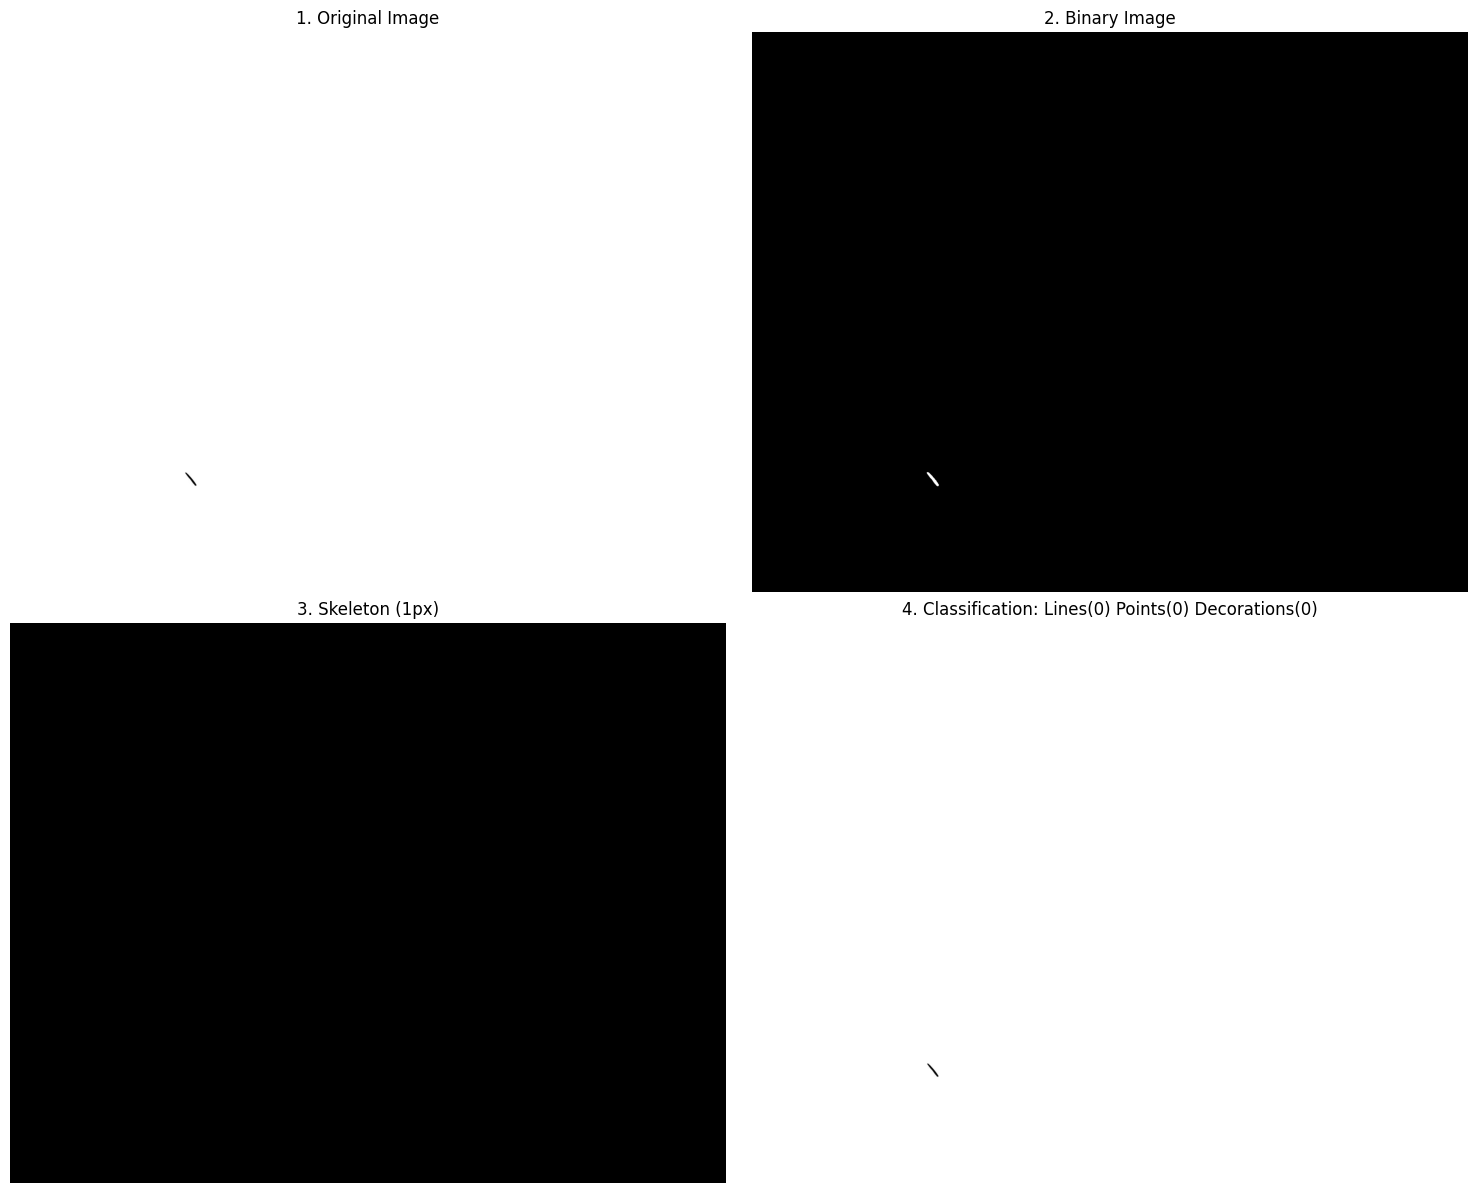

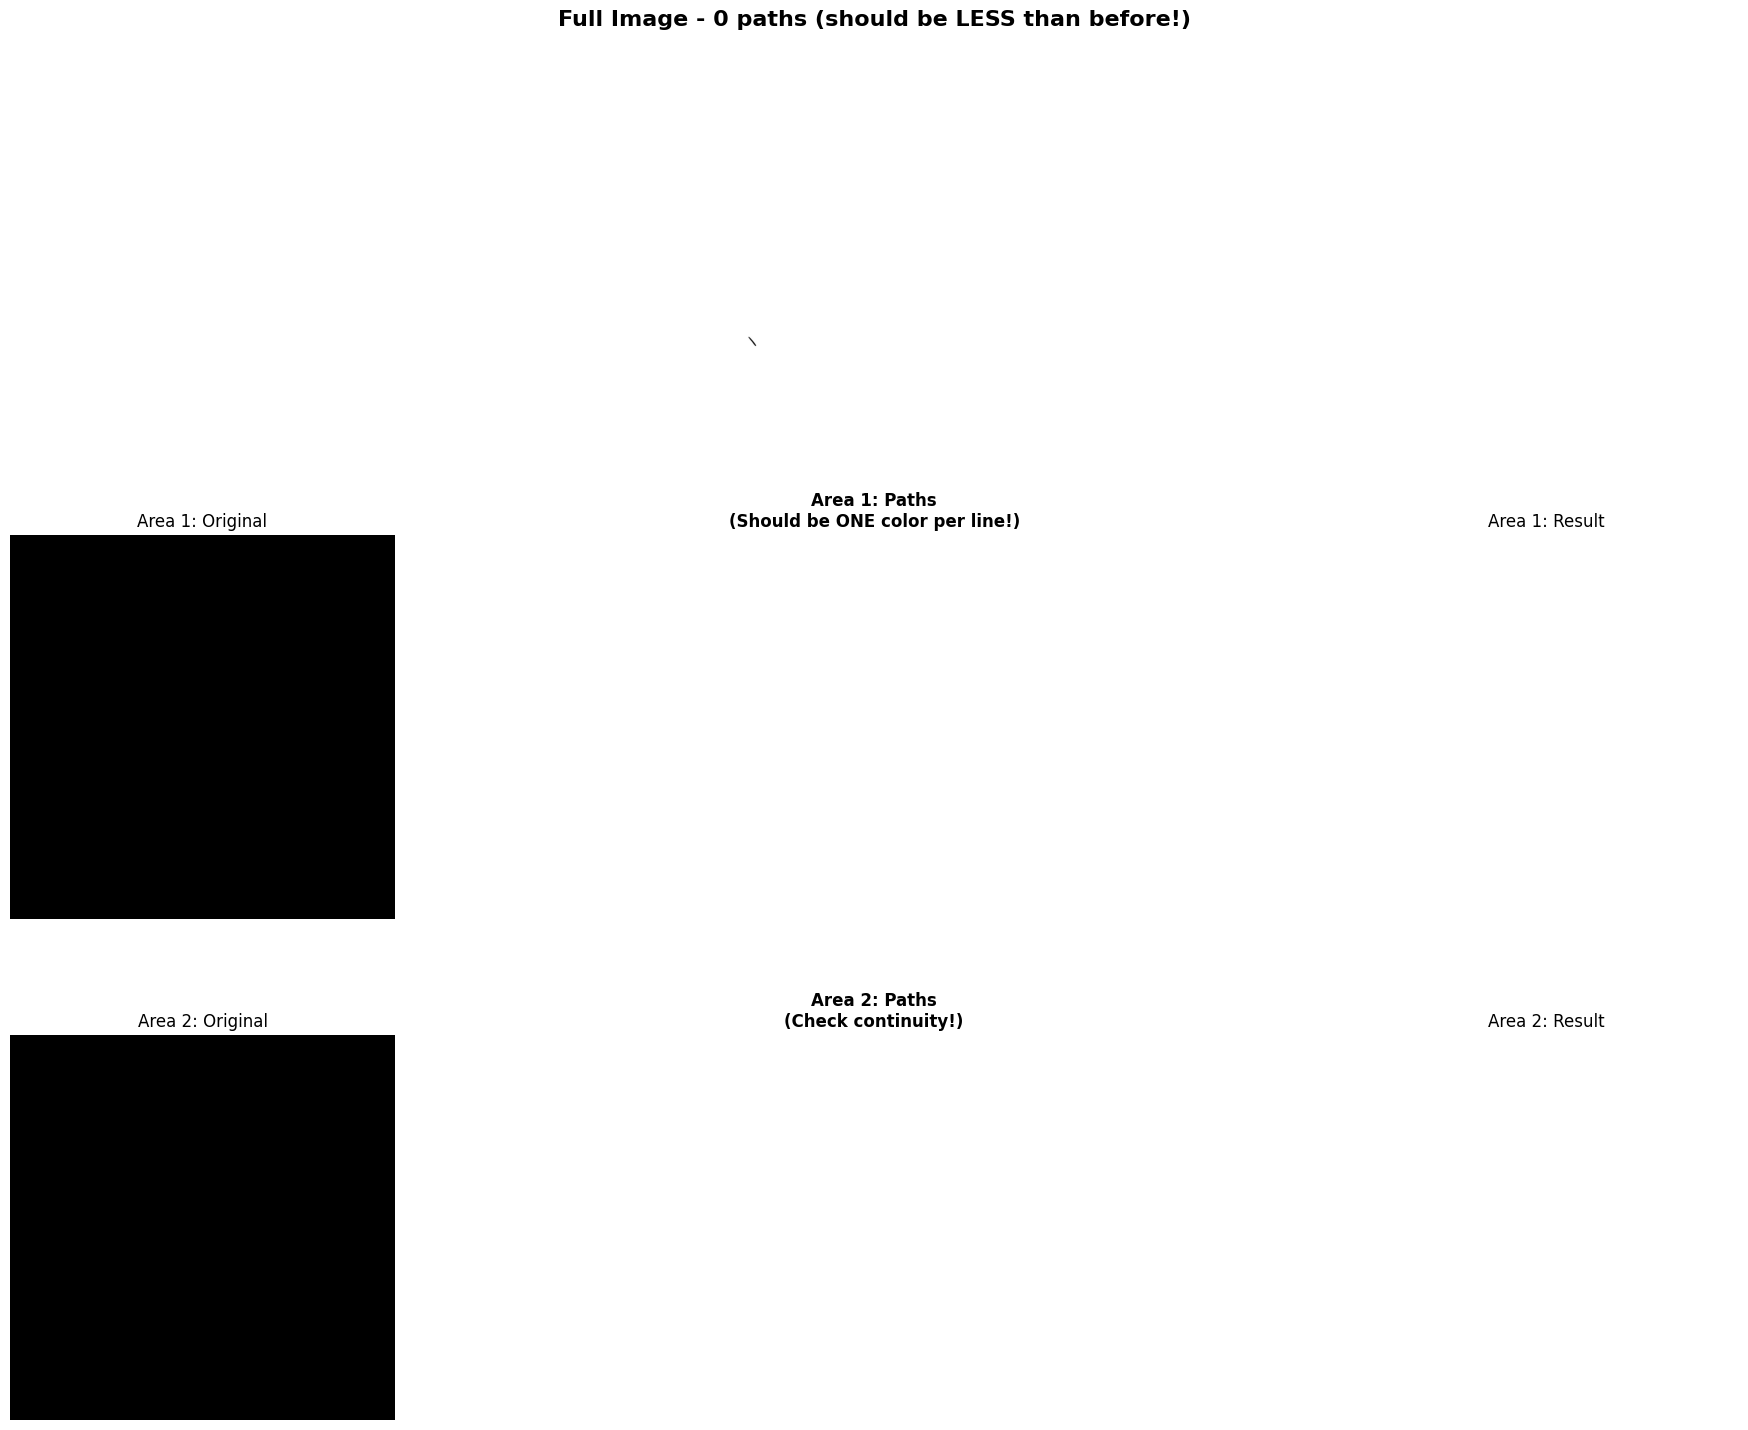


✓ Total paths: 0
✓ Compare with Test 7 (51 paths)
✓ MENO paths = MEGLIO (linee più lunghe e continue!)

🔍 CHECK ZOOMED AREAS:
  - Linee nere dovrebbero avere UN SOLO colore (non frammentate)
  - Meno segmentini colorati diversi vicino ai punti


In [4]:


input_image = "C:\\Users\\larth\\Documents\\PyPotteryTrace\\interactive_app\\uploads\\b10ea504-62ae-47f2-9408-0227863548d6\\vectorize_debug_masks\\03_Continuation_Lines_Continuation_Lines_1.png"

print("=" * 80)
print("VECTORIZER v6.0 - ANTI-FRAGMENTATION FILTER + 100px LOOK-AHEAD")
print("=" * 80)

result = vectorize_archaeological_drawing(
    image_path=input_image,
    output_svg_path="data_vectorized/prova.svg",
    output_jpg_path="data_vectorized/prova_comparison.jpg",
    lines_threshold=10,  # High to get clean lines
    points_threshold=30,
    epsilon=1.0,
    min_dotted_area=10,
    max_dotted_area=200,
    dotted_circularity=0.2,
    dark_threshold=100,
    filter_branches=False,
    smoothing_factor=0.6,
    extract_profile_mode=False,
)

# Display with focus on fragmented areas
fig = plt.figure(figsize=(24, 18))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# Load images
img_original = cv2.imread(input_image, cv2.IMREAD_GRAYSCALE)
img_paths = cv2.imread('diagnostic_paths.png')
img_paths = cv2.cvtColor(img_paths, cv2.COLOR_BGR2RGB)
img_result = cv2.imread('skeleton_debug.png')
img_result = cv2.cvtColor(img_result, cv2.COLOR_BGR2RGB)

# Row 1: Full images
ax1 = fig.add_subplot(gs[0, :])
ax1.imshow(img_paths)
ax1.set_title(f'Full Image - {result["total_paths_extracted"]} paths (should be LESS than before!)', 
              fontsize=16, fontweight='bold')
ax1.axis('off')

# Row 2: Zoom on problematic area 1 (where you showed fragmentation)
zoom1_y, zoom1_x, zoom1_size = 150, 300, 500

ax2 = fig.add_subplot(gs[1, 0])
ax2.imshow(img_original[zoom1_y:zoom1_y+zoom1_size, zoom1_x:zoom1_x+zoom1_size], cmap='gray')
ax2.set_title('Area 1: Original', fontsize=12)
ax2.axis('off')

ax3 = fig.add_subplot(gs[1, 1])
ax3.imshow(img_paths[zoom1_y:zoom1_y+zoom1_size, zoom1_x:zoom1_x+zoom1_size])
ax3.set_title('Area 1: Paths\n(Should be ONE color per line!)', fontsize=12, fontweight='bold')
ax3.axis('off')

ax4 = fig.add_subplot(gs[1, 2])
ax4.imshow(img_result[zoom1_y:zoom1_y+zoom1_size, zoom1_x:zoom1_x+zoom1_size])
ax4.set_title('Area 1: Result', fontsize=12)
ax4.axis('off')

# Row 3: Zoom on problematic area 2 (curved section)
zoom2_y, zoom2_x, zoom2_size = 400, 600, 500

ax5 = fig.add_subplot(gs[2, 0])
ax5.imshow(img_original[zoom2_y:zoom2_y+zoom2_size, zoom2_x:zoom2_x+zoom2_size], cmap='gray')
ax5.set_title('Area 2: Original', fontsize=12)
ax5.axis('off')

ax6 = fig.add_subplot(gs[2, 1])
ax6.imshow(img_paths[zoom2_y:zoom2_y+zoom2_size, zoom2_x:zoom2_x+zoom2_size])
ax6.set_title('Area 2: Paths\n(Check continuity!)', fontsize=12, fontweight='bold')
ax6.axis('off')

ax7 = fig.add_subplot(gs[2, 2])
ax7.imshow(img_result[zoom2_y:zoom2_y+zoom2_size, zoom2_x:zoom2_x+zoom2_size])
ax7.set_title('Area 2: Result', fontsize=12)
ax7.axis('off')

plt.show()

print("\n" + "=" * 80)
print(f"✓ Total paths: {result['total_paths_extracted']}")
print(f"✓ Compare with Test 7 (51 paths)")
print(f"✓ MENO paths = MEGLIO (linee più lunghe e continue!)")
print("=" * 80)
print("\n🔍 CHECK ZOOMED AREAS:")
print("  - Linee nere dovrebbero avere UN SOLO colore (non frammentate)")
print("  - Meno segmentini colorati diversi vicino ai punti")
print("=" * 80)

In [3]:
# Test con diverse tolleranze verticali - VISUALIZZAZIONE PUNTI LIMITE
import matplotlib.pyplot as plt
import cv2
import numpy as np

# Stessa immagine del test precedente
input_image = "C:\\Users\\larth\\Documents\\PyPotteryTrace\\interactive_app\\uploads\\51f97a99-bc81-4b00-8870-58a5523d054b\\vectorize_debug_masks\\02_Profile_Profile_2.png"

# Test con 3 diverse configurazioni di tolleranza
test_configs = [
    {"name": "Stretta (5px)", "confidence": 5, "color": (255, 100, 100)},
    {"name": "Media (15px) - DEFAULT", "confidence": 15, "color": (100, 255, 100)},
    {"name": "Ampia (30px)", "confidence": 30, "color": (100, 100, 255)}
]

results = []

print("=" * 80)
print("TEST: VISUALIZZAZIONE PUNTI LIMITE CON TOLLERANZA VERTICALE")
print("=" * 80)

for config in test_configs:
    print(f"\n{'='*60}")
    print(f"CONFIGURAZIONE: {config['name']}")
    print(f"{'='*60}")
    
    result = vectorize_archaeological_drawing(
        image_path=input_image,
        output_svg_path=f"data_vectorized/profile_conf_{config['confidence']}.svg",
        output_jpg_path=f"data_vectorized/profile_conf_{config['confidence']}_comp.jpg",
        lines_threshold=200,
        points_threshold=30,
        epsilon=1.0,
        min_dotted_area=10,
        max_dotted_area=200,
        dotted_circularity=0.2,
        dark_threshold=100,
        min_decoration_area=20000,
        filter_branches=True,
        smoothing_factor=0.6,
        extract_profile_mode=True,
        profile_vertical_confidence=config['confidence'],
        show_debug_plots=False,
        save_debug_images=False
    )
    
    results.append({
        'config': config,
        'result': result
    })

print("\n" + "=" * 80)
print("ESTRAZIONE COMPLETATA - Pronti per la visualizzazione")
print("=" * 80)

TEST: VISUALIZZAZIONE PUNTI LIMITE CON TOLLERANZA VERTICALE

CONFIGURAZIONE: Stretta (5px)
Archaeological Drawing Vectorizer v2.0
Loading image: C:\Users\larth\Documents\PyPotteryTrace\interactive_app\uploads\51f97a99-bc81-4b00-8870-58a5523d054b\vectorize_debug_masks\02_Profile_Profile_2.png
Image dimensions: 2119 x 1659
Using DUAL THRESHOLD approach...
  - Lines threshold: 200 (higher = only marked lines)
  - Points threshold: 30 (lower = captures faint points)
White pixels in LINES binarization: 4273
White pixels in POINTS binarization: 8439
Separating dotted points, decorations and lines...
Found 5 dotted points
Black areas found: min=24, max=441, avg=168
Found 0 painted decorations (black areas > 20000px)
Found 0 painted decorations
Pixels remaining for lines: 4181
Performing skeletonization of lines...
  Filtering out small circular areas (residual points)...
  Removed 0 small circular components (points)
  Kept 1 line components
  Pixels after point filtering: 4181
  Improving li

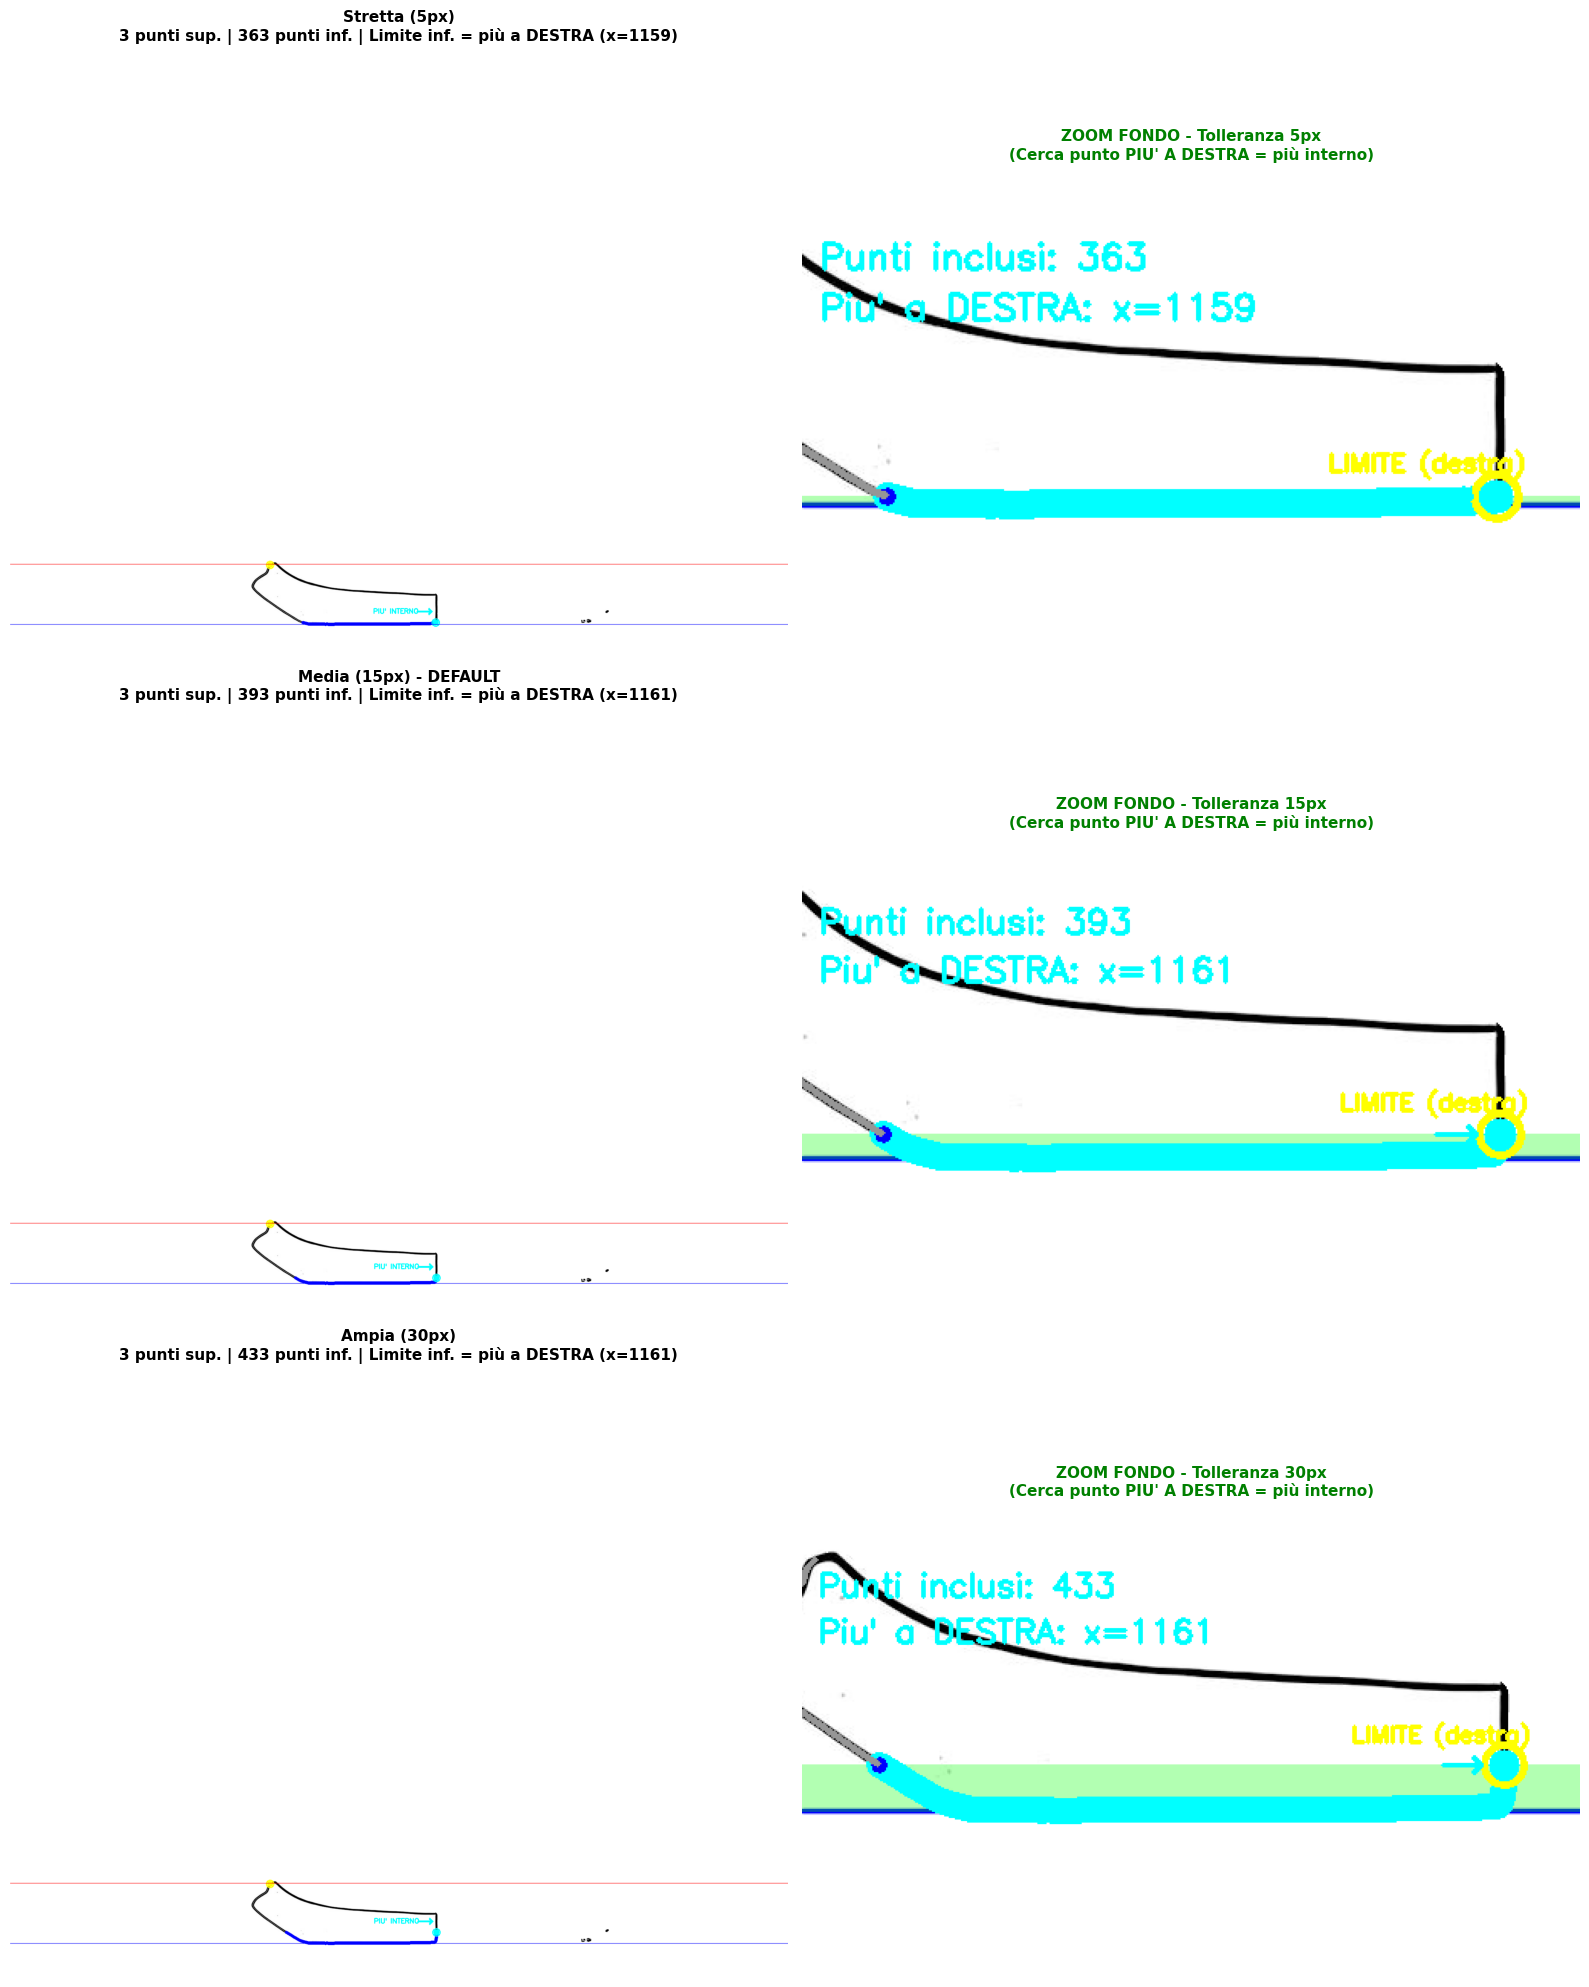


LEGENDA:
VISTA COMPLETA (sinistra):
  🔵 BLU = Punti nel limite SUPERIORE (y minima ± 2px)
  🔴 ROSSO = Punti nel limite INFERIORE (y massima ± tolleranza)
  🩵 CIANO = Punto PIÙ A SINISTRA superiore (inizio profilo esterno)
  🟡 GIALLO = Punto PIÙ A DESTRA inferiore (fine profilo, più interno!)

ZOOM FONDO (destra):
  🟩 VERDE = Zona di tolleranza verticale
  🔴 ROSSO GRANDE = Punti inclusi nella tolleranza
  🟡 CERCHIO GIALLO = Punto limite scelto (PIÙ A DESTRA = più interno)

⚠️  IMPORTANTE: Nel fondo, si cerca il punto PIÙ A DESTRA (più interno)
   perché il vaso è ribaltato e il fondo piatto si estende verso l'interno!


In [4]:
# VISUALIZZAZIONE DETTAGLIATA: PUNTI LIMITE EVIDENZIATI
# CORREZIONE: Il punto inferiore è il più a DESTRA (più interno) nella zona di tolleranza!

img_original = cv2.imread(input_image, cv2.IMREAD_GRAYSCALE)

fig, axes = plt.subplots(3, 2, figsize=(16, 20))

for idx in range(3):
    outer_contour = results[idx]['result']['profile_data']['outer_contour']
    config = test_configs[idx]
    
    # Trova punti limite
    y_coords = outer_contour[:, 0]
    y_top = np.min(y_coords)
    y_bottom = np.max(y_coords)
    
    # Punti nel limite superiore (tolleranza fissa 2px)
    top_points = outer_contour[np.abs(outer_contour[:, 0] - y_top) <= 2]
    
    # Punti nel limite inferiore (tolleranza variabile)
    bottom_points = outer_contour[np.abs(outer_contour[:, 0] - y_bottom) <= config['confidence']]
    
    # Punto più a sinistra superiore e PIÙ A DESTRA inferiore (CORREZIONE!)
    top_left = top_points[np.argmin(top_points[:, 1])]
    bottom_right = bottom_points[np.argmax(bottom_points[:, 1])]  # CAMBIATO: argmax invece di argmin!
    
    # === COLONNA 1: VISTA COMPLETA ===
    ax_full = axes[idx, 0]
    img_display = cv2.cvtColor(img_original, cv2.COLOR_GRAY2BGR)
    
    # Disegna tutto il contorno in grigio chiaro
    for i in range(len(outer_contour) - 1):
        y1, x1 = int(outer_contour[i][0]), int(outer_contour[i][1])
        y2, x2 = int(outer_contour[i+1][0]), int(outer_contour[i+1][1])
        cv2.line(img_display, (x1, y1), (x2, y2), (200, 200, 200), 1)
    
    # Evidenzia i punti del LIMITE SUPERIORE in BLU
    for point in top_points:
        y, x = int(point[0]), int(point[1])
        cv2.circle(img_display, (x, y), 4, (255, 0, 0), -1)
    
    # Evidenzia i punti del LIMITE INFERIORE in ROSSO
    for point in bottom_points:
        y, x = int(point[0]), int(point[1])
        cv2.circle(img_display, (x, y), 4, (0, 0, 255), -1)
    
    # Evidenzia il punto PIÙ A SINISTRA superiore in CIANO
    cv2.circle(img_display, (int(top_left[1]), int(top_left[0])), 8, (255, 255, 0), -1)
    cv2.circle(img_display, (int(top_left[1]), int(top_left[0])), 10, (255, 255, 0), 2)
    
    # Evidenzia il punto PIÙ A DESTRA inferiore in GIALLO (CORREZIONE!)
    cv2.circle(img_display, (int(bottom_right[1]), int(bottom_right[0])), 8, (0, 255, 255), -1)
    cv2.circle(img_display, (int(bottom_right[1]), int(bottom_right[0])), 10, (0, 255, 255), 2)
    
    # Disegna linee orizzontali di riferimento
    cv2.line(img_display, (0, int(y_top)), (img_display.shape[1], int(y_top)), (255, 0, 0), 1, cv2.LINE_AA)
    cv2.line(img_display, (0, int(y_bottom)), (img_display.shape[1], int(y_bottom)), (0, 0, 255), 1, cv2.LINE_AA)
    
    # Aggiungi freccia che indica "più a DESTRA"
    arrow_start_x = int(bottom_right[1]) - 50
    arrow_end_x = int(bottom_right[1]) - 10
    arrow_y = int(bottom_right[0]) - 30
    cv2.arrowedLine(img_display, (arrow_start_x, arrow_y), (arrow_end_x, arrow_y), (0, 255, 255), 3, tipLength=0.3)
    cv2.putText(img_display, "PIU' INTERNO ->", (arrow_start_x - 120, arrow_y + 5), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 255), 2)
    
    ax_full.imshow(img_display)
    ax_full.set_title(f"{config['name']}\n{len(top_points)} punti sup. | {len(bottom_points)} punti inf. | Limite inf. = più a DESTRA (x={bottom_right[1]:.0f})", 
                      fontsize=11, fontweight='bold')
    ax_full.axis('off')
    
    # === COLONNA 2: ZOOM SUL FONDO ===
    ax_zoom = axes[idx, 1]
    
    # Area zoom: 200px sopra il fondo
    y_min_zoom = max(0, int(y_bottom) - 200)
    y_max_zoom = min(img_original.shape[0], int(y_bottom) + 20)
    
    # Range X basato sui punti del fondo
    x_min_zoom = max(0, int(np.min(bottom_points[:, 1])) - 50)
    x_max_zoom = min(img_original.shape[1], int(np.max(bottom_points[:, 1])) + 50)
    
    # Crea zoom
    zoom_img = cv2.cvtColor(img_original[y_min_zoom:y_max_zoom, x_min_zoom:x_max_zoom], cv2.COLOR_GRAY2BGR)
    
    # Disegna la linea del fondo di riferimento
    y_bottom_local = int(y_bottom) - y_min_zoom
    cv2.line(zoom_img, (0, y_bottom_local), (zoom_img.shape[1], y_bottom_local), (0, 0, 255), 2, cv2.LINE_AA)
    
    # Disegna la zona di tolleranza (rettangolo semi-trasparente)
    overlay = zoom_img.copy()
    y_tolerance_top = max(0, y_bottom_local - config['confidence'])
    cv2.rectangle(overlay, (0, y_tolerance_top), (zoom_img.shape[1], y_bottom_local), (0, 255, 0), -1)
    zoom_img = cv2.addWeighted(zoom_img, 0.7, overlay, 0.3, 0)
    
    # Disegna TUTTI i punti del contorno nell'area zoom
    for point in outer_contour:
        y, x = int(point[0]), int(point[1])
        if y_min_zoom <= y < y_max_zoom and x_min_zoom <= x < x_max_zoom:
            y_local = y - y_min_zoom
            x_local = x - x_min_zoom
            
            # Punti nel limite inferiore (entro la tolleranza) = ROSSO GRANDE
            if abs(y - y_bottom) <= config['confidence']:
                cv2.circle(zoom_img, (x_local, y_local), 5, (0, 0, 255), -1)
                cv2.circle(zoom_img, (x_local, y_local), 7, (0, 255, 255), 2)
            else:
                # Altri punti = grigio piccolo
                cv2.circle(zoom_img, (x_local, y_local), 2, (150, 150, 150), -1)
    
    # Evidenzia il punto PIÙ A DESTRA del fondo (CORREZIONE!)
    if y_min_zoom <= bottom_right[0] < y_max_zoom and x_min_zoom <= bottom_right[1] < x_max_zoom:
        y_local = int(bottom_right[0]) - y_min_zoom
        x_local = int(bottom_right[1]) - x_min_zoom
        cv2.circle(zoom_img, (x_local, y_local), 10, (0, 255, 255), -1)
        cv2.circle(zoom_img, (x_local, y_local), 13, (255, 255, 0), 3)
        cv2.putText(zoom_img, "LIMITE (destra)", (x_local - 100, y_local - 15), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 0), 2)
        
        # Freccia che indica che è il più a destra
        cv2.arrowedLine(zoom_img, (x_local - 40, y_local), (x_local - 15, y_local), (0, 255, 255), 2, tipLength=0.3)
    
    # Annotazioni
    cv2.putText(zoom_img, f"Tolleranza: {config['confidence']}px", (10, 30), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
    cv2.putText(zoom_img, f"Punti inclusi: {len(bottom_points)}", (10, 60), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)
    cv2.putText(zoom_img, f"Piu' a DESTRA: x={bottom_right[1]:.0f}", (10, 90), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)
    
    ax_zoom.imshow(zoom_img)
    ax_zoom.set_title(f"ZOOM FONDO - Tolleranza {config['confidence']}px\n(Cerca punto PIU' A DESTRA = più interno)", 
                     fontsize=11, fontweight='bold', color='green')
    ax_zoom.axis('off')

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("LEGENDA:")
print("=" * 80)
print("VISTA COMPLETA (sinistra):")
print("  🔵 BLU = Punti nel limite SUPERIORE (y minima ± 2px)")
print("  🔴 ROSSO = Punti nel limite INFERIORE (y massima ± tolleranza)")
print("  🩵 CIANO = Punto PIÙ A SINISTRA superiore (inizio profilo esterno)")
print("  🟡 GIALLO = Punto PIÙ A DESTRA inferiore (fine profilo, più interno!)")
print("\nZOOM FONDO (destra):")
print("  🟩 VERDE = Zona di tolleranza verticale")
print("  🔴 ROSSO GRANDE = Punti inclusi nella tolleranza")
print("  🟡 CERCHIO GIALLO = Punto limite scelto (PIÙ A DESTRA = più interno)")
print("\n⚠️  IMPORTANTE: Nel fondo, si cerca il punto PIÙ A DESTRA (più interno)")
print("   perché il vaso è ribaltato e il fondo piatto si estende verso l'interno!")
print("=" * 80)

In [ ]:
# ANALISI NUMERICA: Confronto tra configurazioni
# CORREZIONE: Mostra che il punto inferiore è il PIÙ A DESTRA

print("=" * 80)
print("ANALISI DETTAGLIATA DEI PUNTI LIMITE")
print("CORREZIONE: Limite inferiore = punto PIÙ A DESTRA (più interno)")
print("=" * 80)

for idx, r in enumerate(results):
    config = r['config']
    outer_contour = r['result']['profile_data']['outer_contour']
    
    # Calcola statistiche
    y_coords = outer_contour[:, 0]
    y_top = np.min(y_coords)
    y_bottom = np.max(y_coords)
    
    top_points = outer_contour[np.abs(outer_contour[:, 0] - y_top) <= 2]
    bottom_points = outer_contour[np.abs(outer_contour[:, 0] - y_bottom) <= config['confidence']]
    
    top_left = top_points[np.argmin(top_points[:, 1])]
    bottom_right = bottom_points[np.argmax(bottom_points[:, 1])]  # PIÙ A DESTRA!
    
    print(f"\n{'='*60}")
    print(f"CONFIGURAZIONE: {config['name']}")
    print(f"{'='*60}")
    print(f"\n📐 LIMITI VERTICALI:")
    print(f"   Y superiore (top):    {y_top:.1f}px")
    print(f"   Y inferiore (bottom): {y_bottom:.1f}px")
    print(f"   Altezza profilo:      {y_bottom - y_top:.1f}px")
    
    print(f"\n🔵 LIMITE SUPERIORE:")
    print(f"   Tolleranza:           2px (fissa)")
    print(f"   Punti trovati:        {len(top_points)}")
    print(f"   Range X:              {np.min(top_points[:, 1]):.1f} - {np.max(top_points[:, 1]):.1f}px")
    print(f"   Punto scelto (SX):    y={top_left[0]:.1f}, x={top_left[1]:.1f}")
    
    print(f"\n🔴 LIMITE INFERIORE:")
    print(f"   Tolleranza:           {config['confidence']}px")
    print(f"   Punti trovati:        {len(bottom_points)}")
    print(f"   Range Y punti:        {np.min(bottom_points[:, 0]):.1f} - {np.max(bottom_points[:, 0]):.1f}px")
    print(f"   Range X punti:        {np.min(bottom_points[:, 1]):.1f} - {np.max(bottom_points[:, 1]):.1f}px")
    print(f"   Punto scelto (DX):    y={bottom_right[0]:.1f}, x={bottom_right[1]:.1f} ⬅️ PIÙ A DESTRA!")
    print(f"   Shift verticale:      {y_bottom - bottom_right[0]:.1f}px dal fondo assoluto")
    print(f"   Shift orizzontale:    {bottom_right[1] - np.min(bottom_points[:, 1]):.1f}px dal bordo sinistro")
    
    print(f"\n📊 PROFILO ESTRATTO:")
    print(f"   Punti totali:         {len(outer_contour)}")
    print(f"   Lunghezza profilo:    ~{len(outer_contour) * 1.5:.0f}px (stima)")
    
    # Confronto con punto più a SINISTRA (vecchio metodo)
    bottom_left_old = bottom_points[np.argmin(bottom_points[:, 1])]
    print(f"\n⚠️  CONFRONTO CON VECCHIO METODO (più a sinistra):")
    print(f"   Vecchio punto (SX):   y={bottom_left_old[0]:.1f}, x={bottom_left_old[1]:.1f}")
    print(f"   Differenza X:         {bottom_right[1] - bottom_left_old[1]:.1f}px (quanto più interno)")

print("\n" + "=" * 80)
print("💡 INTERPRETAZIONE:")
print("=" * 80)
print("• TOLLERANZA BASSA (5px):  Più precisa, ma può tagliare fondi piatti")
print("• TOLLERANZA MEDIA (15px): Bilanciamento - cattura fondi piatti moderati")
print("• TOLLERANZA ALTA (30px):  Include più punti - per fondi molto piatti")
print()
print("• ⚠️  CORREZIONE IMPORTANTE: Nel limite INFERIORE si cerca il punto PIÙ A DESTRA")
print("  perché il vaso è ribaltato e il fondo piatto si estende verso l'INTERNO (destra)")
print("• Lo 'shift verticale' mostra quanto il punto scelto è sopra il fondo assoluto")
print("• Lo 'shift orizzontale' mostra quanto il punto è più interno rispetto al bordo")
print("=" * 80)

ANALISI DETTAGLIATA DEI PUNTI LIMITE
CORREZIONE: Limite inferiore = punto PIÙ A DESTRA (più interno)

CONFIGURAZIONE: Stretta (5px)

📐 LIMITI VERTICALI:
   Y superiore (top):    1403.0px
   Y inferiore (bottom): 1567.0px
   Altezza profilo:      164.0px

🔵 LIMITE SUPERIORE:
   Tolleranza:           2px (fissa)
   Punti trovati:        3
   Range X:              708.0 - 710.0px
   Punto scelto (SX):    y=1405.0, x=708.0

🔴 LIMITE INFERIORE:
   Tolleranza:           5px
   Punti trovati:        363
   Range Y punti:        1562.0 - 1567.0px
   Range X punti:        797.0 - 1159.0px
   Punto scelto (DX):    y=1562.0, x=1159.0 ⬅️ PIÙ A DESTRA!
   Shift verticale:      5.0px dal fondo assoluto
   Shift orizzontale:    362.0px dal bordo sinistro

📊 PROFILO ESTRATTO:
   Punti totali:         572
   Lunghezza profilo:    ~858px (stima)

⚠️  CONFRONTO CON VECCHIO METODO (più a sinistra):
   Vecchio punto (SX):   y=1562.0, x=797.0
   Differenza X:         362.0px (quanto più interno)

CONFIGURAZ

: 

# Test: Tolleranza Verticale per Fondi Piatti

Confrontiamo 3 configurazioni:
1. **Tolleranza standard** (2px) - comportamento originale
2. **Tolleranza media** (15px) - default nuovo parametro
3. **Tolleranza alta** (30px) - per fondi molto piatti

In [ ]:
# Verifica che le curve siano chiuse
import xml.etree.ElementTree as ET

print("=" * 80)
print("VERIFICA CURVE CHIUSE NEI FILE SVG")
print("=" * 80)

for idx, config in enumerate(test_configs):
    svg_file = f"data_vectorized/profile_conf_{config['confidence']}.svg"
    
    print(f"\n{'='*60}")
    print(f"File: {svg_file}")
    print(f"Configurazione: {config['name']}")
    print(f"{'='*60}")
    
    try:
        # Parse SVG
        tree = ET.parse(svg_file)
        root = tree.getroot()
        
        # Namespace SVG
        ns = {'svg': 'http://www.w3.org/2000/svg'}
        
        # Trova tutti i path nel gruppo "lines"
        paths = root.findall(".//svg:g[@id='lines']/svg:path", ns)
        
        print(f"\nTrovati {len(paths)} path nel gruppo 'lines'")
        
        for i, path in enumerate(paths, 1):
            d = path.get('d', '')
            
            # Verifica se termina con 'Z' (chiusura)
            is_closed_svg = d.strip().endswith('Z')
            
            # Estrai primo e ultimo punto per verifica manuale
            # Regex per estrarre coordinate
            import re
            coords = re.findall(r'([ML])\s*([\d.]+),([\d.]+)', d)
            
            if len(coords) >= 2:
                first_cmd, first_x, first_y = coords[0]
                last_cmd, last_x, last_y = coords[-1]
                
                # Calcola distanza
                distance = ((float(first_x) - float(last_x))**2 + 
                           (float(first_y) - float(last_y))**2)**0.5
                
                print(f"\n  Path #{i}:")
                print(f"    Primi 50 caratteri: {d[:50]}...")
                print(f"    Ultimi 50 caratteri: ...{d[-50:]}")
                print(f"    Termina con 'Z': {'✅ SÌ' if is_closed_svg else '❌ NO'}")
                print(f"    Primo punto: ({first_x}, {first_y})")
                print(f"    Ultimo punto: ({last_x}, {last_y})")
                print(f"    Distanza inizio-fine: {distance:.2f}px")
                
                if is_closed_svg:
                    print(f"    ✅ CURVA CHIUSA (comando 'Z' presente)")
                elif distance < 5:
                    print(f"    ⚠️  Punti vicini ma manca 'Z' - dovrebbe essere chiusa!")
                else:
                    print(f"    ❌ CURVA APERTA (distanza {distance:.2f}px)")
    
    except Exception as e:
        print(f"Errore nel parsing SVG: {e}")
    
    # Verifica anche i dati del profilo
    if 'profile_data' in results[idx]['result']:
        outer_contour = results[idx]['result']['profile_data']['outer_contour']
        
        if len(outer_contour) >= 2:
            start = outer_contour[0]
            end = outer_contour[-1]
            dist = np.linalg.norm(start - end)
            
            print(f"\n  Dati profilo in memoria:")
            print(f"    Punti totali: {len(outer_contour)}")
            print(f"    Primo punto: y={start[0]:.1f}, x={start[1]:.1f}")
            print(f"    Ultimo punto: y={end[0]:.1f}, x={end[1]:.1f}")
            print(f"    Distanza: {dist:.2f}px")
            print(f"    {'✅ CHIUSO' if dist < 5 else '❌ APERTO'}")

print("\n" + "=" * 80)
print("RIEPILOGO:")
print("  ✅ = Curva chiusa correttamente")
print("  ⚠️  = Punti vicini ma comando 'Z' mancante")
print("  ❌ = Curva aperta (problema!)")
print("=" * 80)

## Verifica: Curve Chiuse

Verifichiamo che i profili estratti siano effettivamente curve **chiuse**.